# Previsibilidad y volatilidad de la inflación global
### Un recorrido completo: de la fuente cruda a un modelo multivariado auditado

---

## 0. Introducción

**La pregunta de investigación:** ¿qué tan predecible es la inflación mes a mes, y de qué depende esa previsibilidad? No "¿cuál va a ser la inflación de mayo?" — una pregunta mucho más modesta y, para un analista o un banco central, mucho más útil: **¿en qué países y en qué circunstancias vale la pena confiar en un modelo, y en cuáles el mejor pronóstico posible es simplemente "el mes que viene se va a parecer al anterior"?**

Por qué importa: la política monetaria se diseña con una previsibilidad *asumida* de la inflación — los bancos centrales fijan metas y ajustan tasas asumiendo que sus modelos capturan la dinámica real. Si esa previsibilidad varía sistemáticamente según el nivel de desarrollo del país, el régimen de inflación o el componente de la canasta, esa heterogeneidad debería informar cuánta confianza depositar en cualquier pronóstico puntual.

**Qué se va a encontrar en este documento:** un pipeline completo — descarga de datos, cinco fases de auditoría de la fuente, un ETL corregido con trazabilidad total, ~640 modelos ARIMA y ~626 modelos GARCH ajustados y validados con walk-forward contra un baseline ingenuo, cinco hallazgos centrales, y una auto-auditoría metodológica que puso a prueba esos hallazgos con intervalos de confianza y un modelo multivariado antes de darlos por buenos.

Este notebook no re-ejecuta el modelado completo (eso tardaría ~15 minutos y ya está hecho — ver `run_pipeline.py`); carga los resultados ya generados y los recorre en orden narrativo, con las decisiones y su porqué en cada paso. La única excepción es la Sección 4, donde se ajustan 1-2 modelos ilustrativos en vivo para que se *vea* qué hace el modelo, no solo se lea sobre él.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGS = ROOT / "reports" / "figures"

print(f"Raiz del proyecto: {ROOT}")
print(f"Figuras: {FIGS}")

Raiz del proyecto: C:\Users\matia\OneDrive\Escritorio\Mis documentos\PROYECTOS Y CURSOS\global-inflation-arima-garch
Figuras: C:\Users\matia\OneDrive\Escritorio\Mis documentos\PROYECTOS Y CURSOS\global-inflation-arima-garch\reports\figures


---
## 1. Los datos

La fuente es el **Global Database of Inflation** del Banco Mundial (Ha, Kose & Ohnsorge), un único archivo Excel con **20 hojas**: 6 indicadores de precios (headline CPI, CPI energía, CPI alimentos, CPI núcleo, PPI y deflactor del PIB) en 3 frecuencias (mensual, trimestral, anual), más hojas de metadatos y agregados regionales.

Se usaron los **5 indicadores con frecuencia mensual** — `hcpi_m, ecpi_m, fcpi_m, ccpi_m, ppi_m` — porque el deflactor del PIB (`def`) solo existe trimestral/anual en esta fuente, y porque la frecuencia mensual es la que le da a GARCH suficientes observaciones para estimar volatilidad de forma estable (con datos anuales, el piso de ~100 observaciones que exige GARCH habría significado 100 años de historia).

Cada hoja mensual viene en **formato ancho**: una fila por país, una columna por mes (663 columnas, 1970-01 a 2025-03). El ETL las transforma a formato largo y calcula la inflación interanual.

In [2]:
df = pd.read_parquet(ROOT / "data" / "processed" / "inflacion_mensual_completa_v2.parquet")

print(f"Filas: {len(df):,}")
print(f"Paises: {df['codigo_pais'].nunique()}")
print(f"Indicadores: {sorted(df['indicador'].unique())}")
print(f"Rango de fechas: {df['fecha'].min().date()} a {df['fecha'].max().date()}")
print(f"Series (pais x indicador): {df.groupby(['codigo_pais', 'indicador']).ngroups}")
print()
df.sort_values(["codigo_pais", "indicador", "fecha"]).head(8)

Filas: 217,226
Paises: 188
Indicadores: ['ccpi', 'ecpi', 'fcpi', 'hcpi', 'ppi']
Rango de fechas: 1970-01-01 a 2025-03-01
Series (pais x indicador): 676



,pais,codigo_pais,indicador,fecha,indice,inflacion_yoy_pct,inflacion_yoy_log,tratamiento_indicator_type,patron_frecuencia,alta_inflacion,n_meses_validos,clasificacion_cobertura,apto_arima,apto_garch,dedup_conflicto_recencia
30098,Aruba,ABW,ecpi,2001-01-01,66.711,NaN,NaN,index,mensual,False,230,arranque tardío,True,True,False
30099,Aruba,ABW,ecpi,2001-02-01,66.211,NaN,NaN,index,mensual,False,230,arranque tardío,True,True,False
30100,Aruba,ABW,ecpi,2001-03-01,66.468,NaN,NaN,index,mensual,False,230,arranque tardío,True,True,False
30101,Aruba,ABW,ecpi,2001-04-01,66.620,NaN,NaN,index,mensual,False,230,arranque tardío,True,True,False
30102,Aruba,ABW,ecpi,2001-05-01,66.524,NaN,NaN,index,mensual,False,230,arranque tardío,True,True,False
30103,Aruba,ABW,ecpi,2001-06-01,66.713,NaN,NaN,index,mensual,False,230,arranque tardío,True,True,False
30104,Aruba,ABW,ecpi,2001-07-01,67.091,NaN,NaN,index,mensual,False,230,arranque tardío,True,True,False
30105,Aruba,ABW,ecpi,2001-08-01,66.695,NaN,NaN,index,mensual,False,230,arranque tardío,True,True,False


Cada fila es un país, un indicador y un mes, con el **índice crudo** (nivel, base ~100 en algún año) y dos transformaciones de inflación interanual: `inflacion_yoy_pct` (la unidad estándar, % — "la inflación de enero fue 4.2% interanual") e `inflacion_yoy_log`, la que efectivamente alimenta los modelos (más sobre esto en la Fase 4).

---
## 2. Diagnóstico: 5 fases antes de tocar un solo dato

Antes de corregir nada, el proyecto corrió **cinco fases de auditoría pura** — cada una un script reproducible que documenta problemas sin modificar los datos. La razón de separar diagnóstico de corrección tan estrictamente: este dataset resultó tener suficientes problemas entrelazados (duplicados, filas mal tipeadas, ceros-placeholder, desfasajes de frecuencia) como para que corregir sobre la marcha, fase a fase, hubiera significado tomar decisiones con información parcial.

### Fase 1 — Entender la fuente

Confirmó programáticamente que las hojas `_m`/`_q` son índice y las `_a` son tasa — con una excepción (`def_a` usa la etiqueta `'Rate'`, no `'Inflation'`, mismo significado). El hallazgo crítico: **las 5 hojas mensuales no son homogéneas** en `Indicator Type`. India e Indonesia en `ecpi_m` ya vienen como tasa (no índice); Islas Vírgenes Británicas (`hcpi_m`) y Australia (`ppi_m`) están mal etiquetadas pero sí son índice.

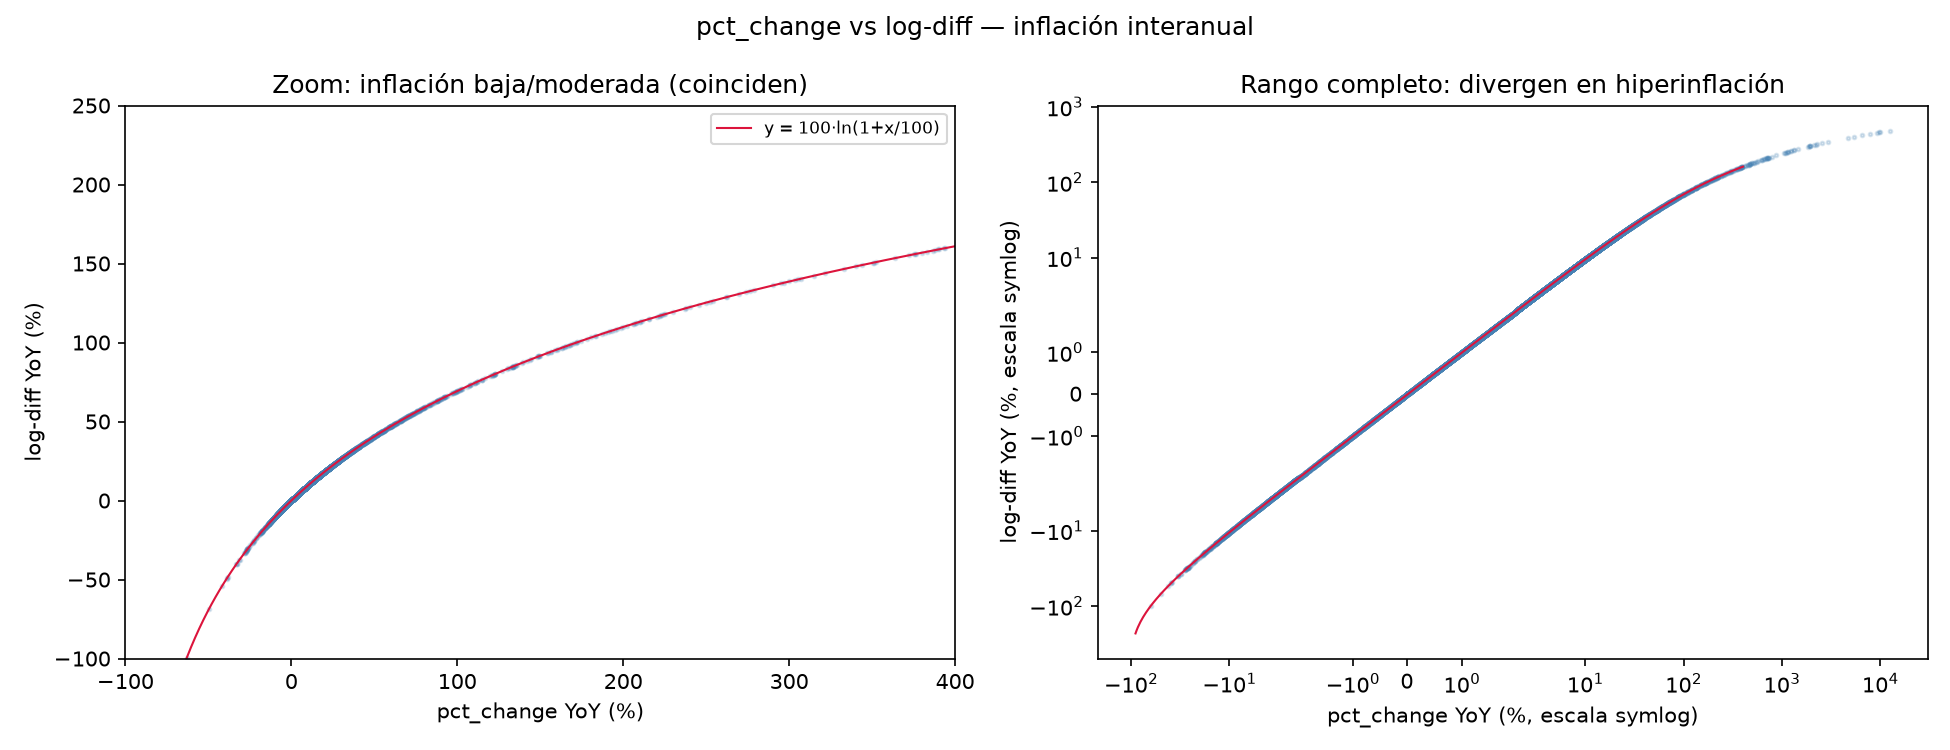

In [3]:
display(Image(filename=str(FIGS / "fase4_pct_vs_logdiff.png")))

*(Esta figura es de Fase 4, pero ilustra bien por qué la heterogeneidad de Fase 1 importa: `pct_change` y `log-diff` son transformaciones equivalentes para inflación normal — panel izquierdo — pero divergen fuerte en hiperinflación — panel derecho, escala symlog. Si una fila ya es tasa y se le aplica `pct_change` como si fuera índice, el resultado es basura, no una transformación de más.)*

### Fase 2 — Integridad estructural

Auditoría sobre el Excel crudo: **36 país-hoja con `Country Code` duplicado** (30 de ellos solo en `ecpi_m` — mucho más de lo que parecía mirando una sola hoja), filas de nota/footnote sin ISO3 válido, y un hallazgo nuevo: **Venezuela con índice exactamente 0.0** durante ~51-60 meses en `ecpi_m`/`fcpi_m` — económicamente imposible para un índice de precios, evidencia de un placeholder de dato faltante mal codificado.

### Fase 3 — Cobertura temporal

Clasificó cada serie por patrón de huecos y aplicó pisos de 60 meses (ARIMA) y 100 meses (GARCH): **636 series modelables para ARIMA, 624 para GARCH**, de 672 series con datos utilizables. Encontró además que el desfasaje de frecuencia (datos trimestrales cargados en la hoja "mensual") es un fenómeno **por serie individual, no por país** — Belice mezcla tramos trimestrales y mensuales en sus 3 indicadores, pero Irlanda e Islandia son 100% mensuales en `hcpi_m` y solo mezclan en `fcpi_m`.

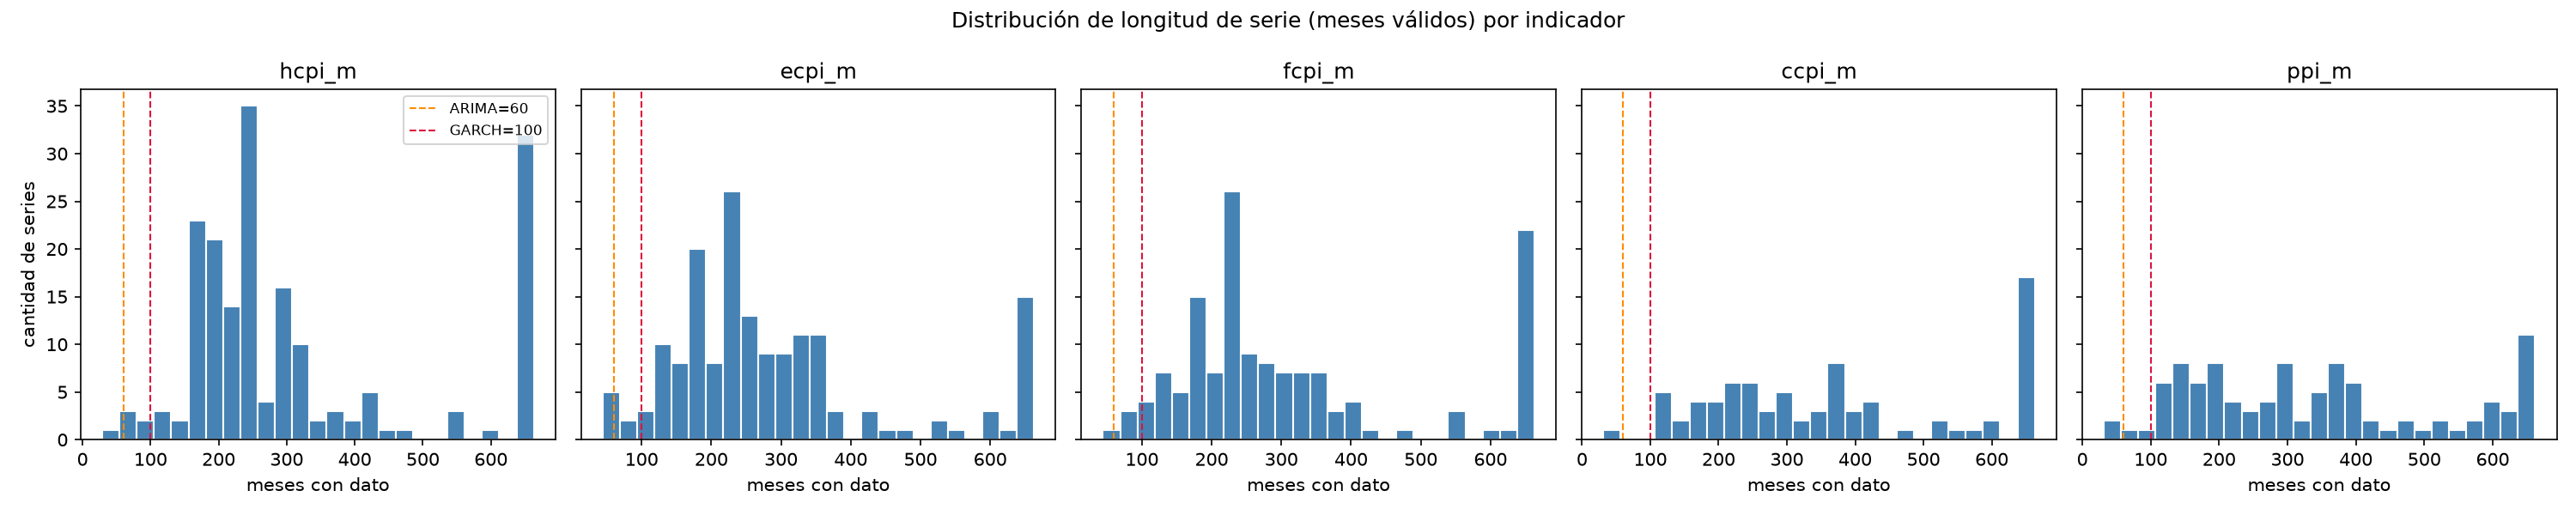

In [4]:
display(Image(filename=str(FIGS / "fase3_distribucion_longitud_por_indicador.png")))

### Fase 4 — Estadística univariada: ¿`pct_change` o `log-diff`?

El objetivo central de esta fase era decidir, con evidencia, cómo calcular la inflación interanual. El hallazgo: ambas fórmulas son casi intercambiables para inflación baja/moderada, pero `log-diff` es muchísimo más estable numéricamente en la cola — el mismo evento real (Venezuela PPI, enero 2019) mide **344.272% en `pct_change`** contra **814% en `log-diff`**. La "prueba de oro" de la fase: reconstruir la tasa anual oficial del Banco Mundial (`hcpi_a`) a partir del índice mensual reprodujo la cifra publicada con una mediana de error de ~0.00001 puntos porcentuales — confirmando que el índice crudo y la fórmula estaban bien calculados.

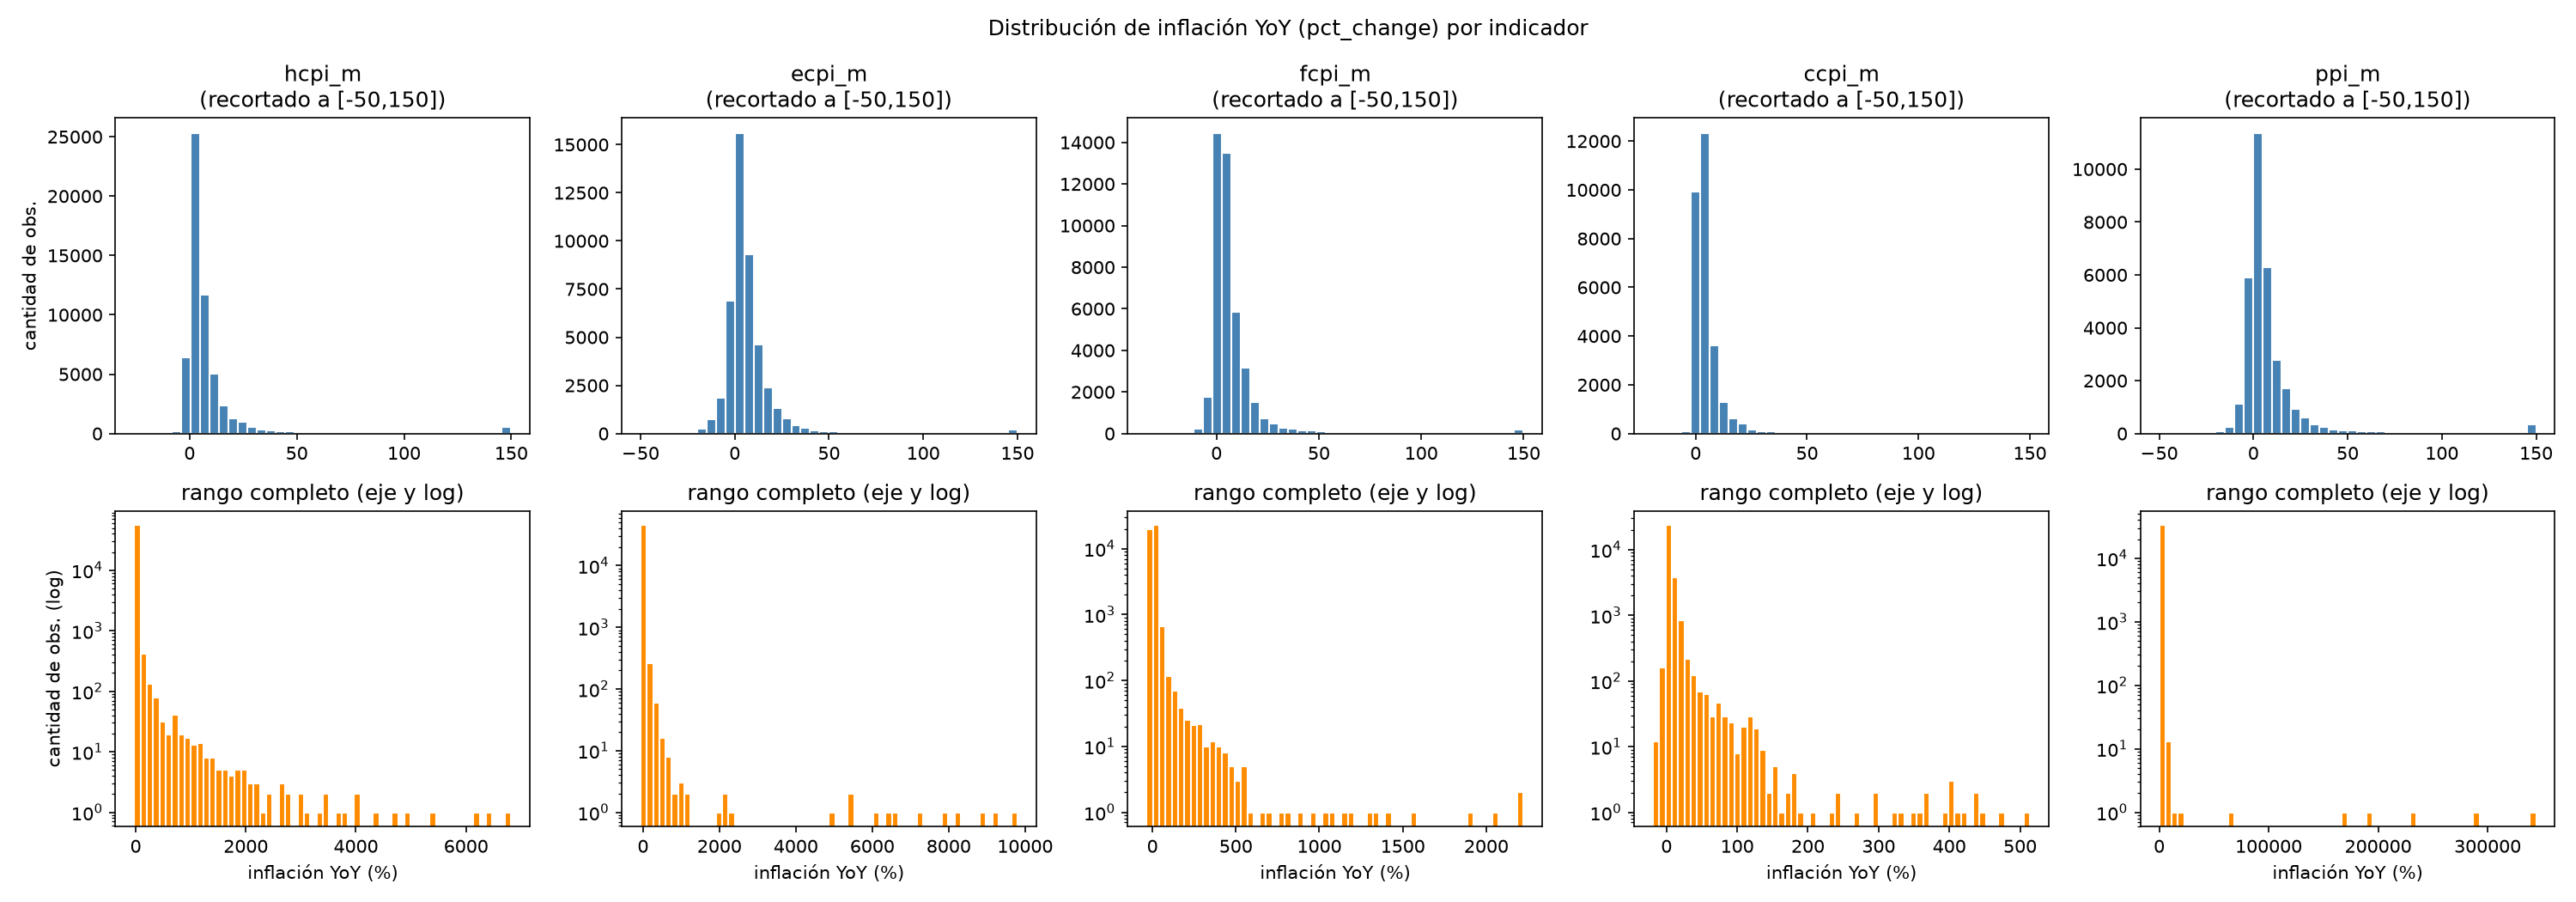

In [5]:
display(Image(filename=str(FIGS / "fase4_distribucion_por_indicador.png")))

### Fase 5 — Series de tiempo: ¿tienen sustento ARIMA y GARCH en estos datos?

- **Estacionariedad** (ADF+KPSS): 68% de las series apto_arima son estacionarias en nivel (d=0), 32% necesita una diferenciación (d=1) — el rango `d∈{0,1,2}` usado en el modelado sale directamente de acá.
- **Autocorrelación**: confirmada en las 8 series de muestra (perfiles de USA a Argentina) — hay estructura real que ARIMA puede capturar.
- **Test ARCH (Engle)** — la validación clave para GARCH: **91.2%** de las series `apto_garch` muestran efecto ARCH significativo, y ese efecto **no está concentrado en países de alta inflación** — GARCH tiene sustento amplio en el panel, no es un capricho metodológico.

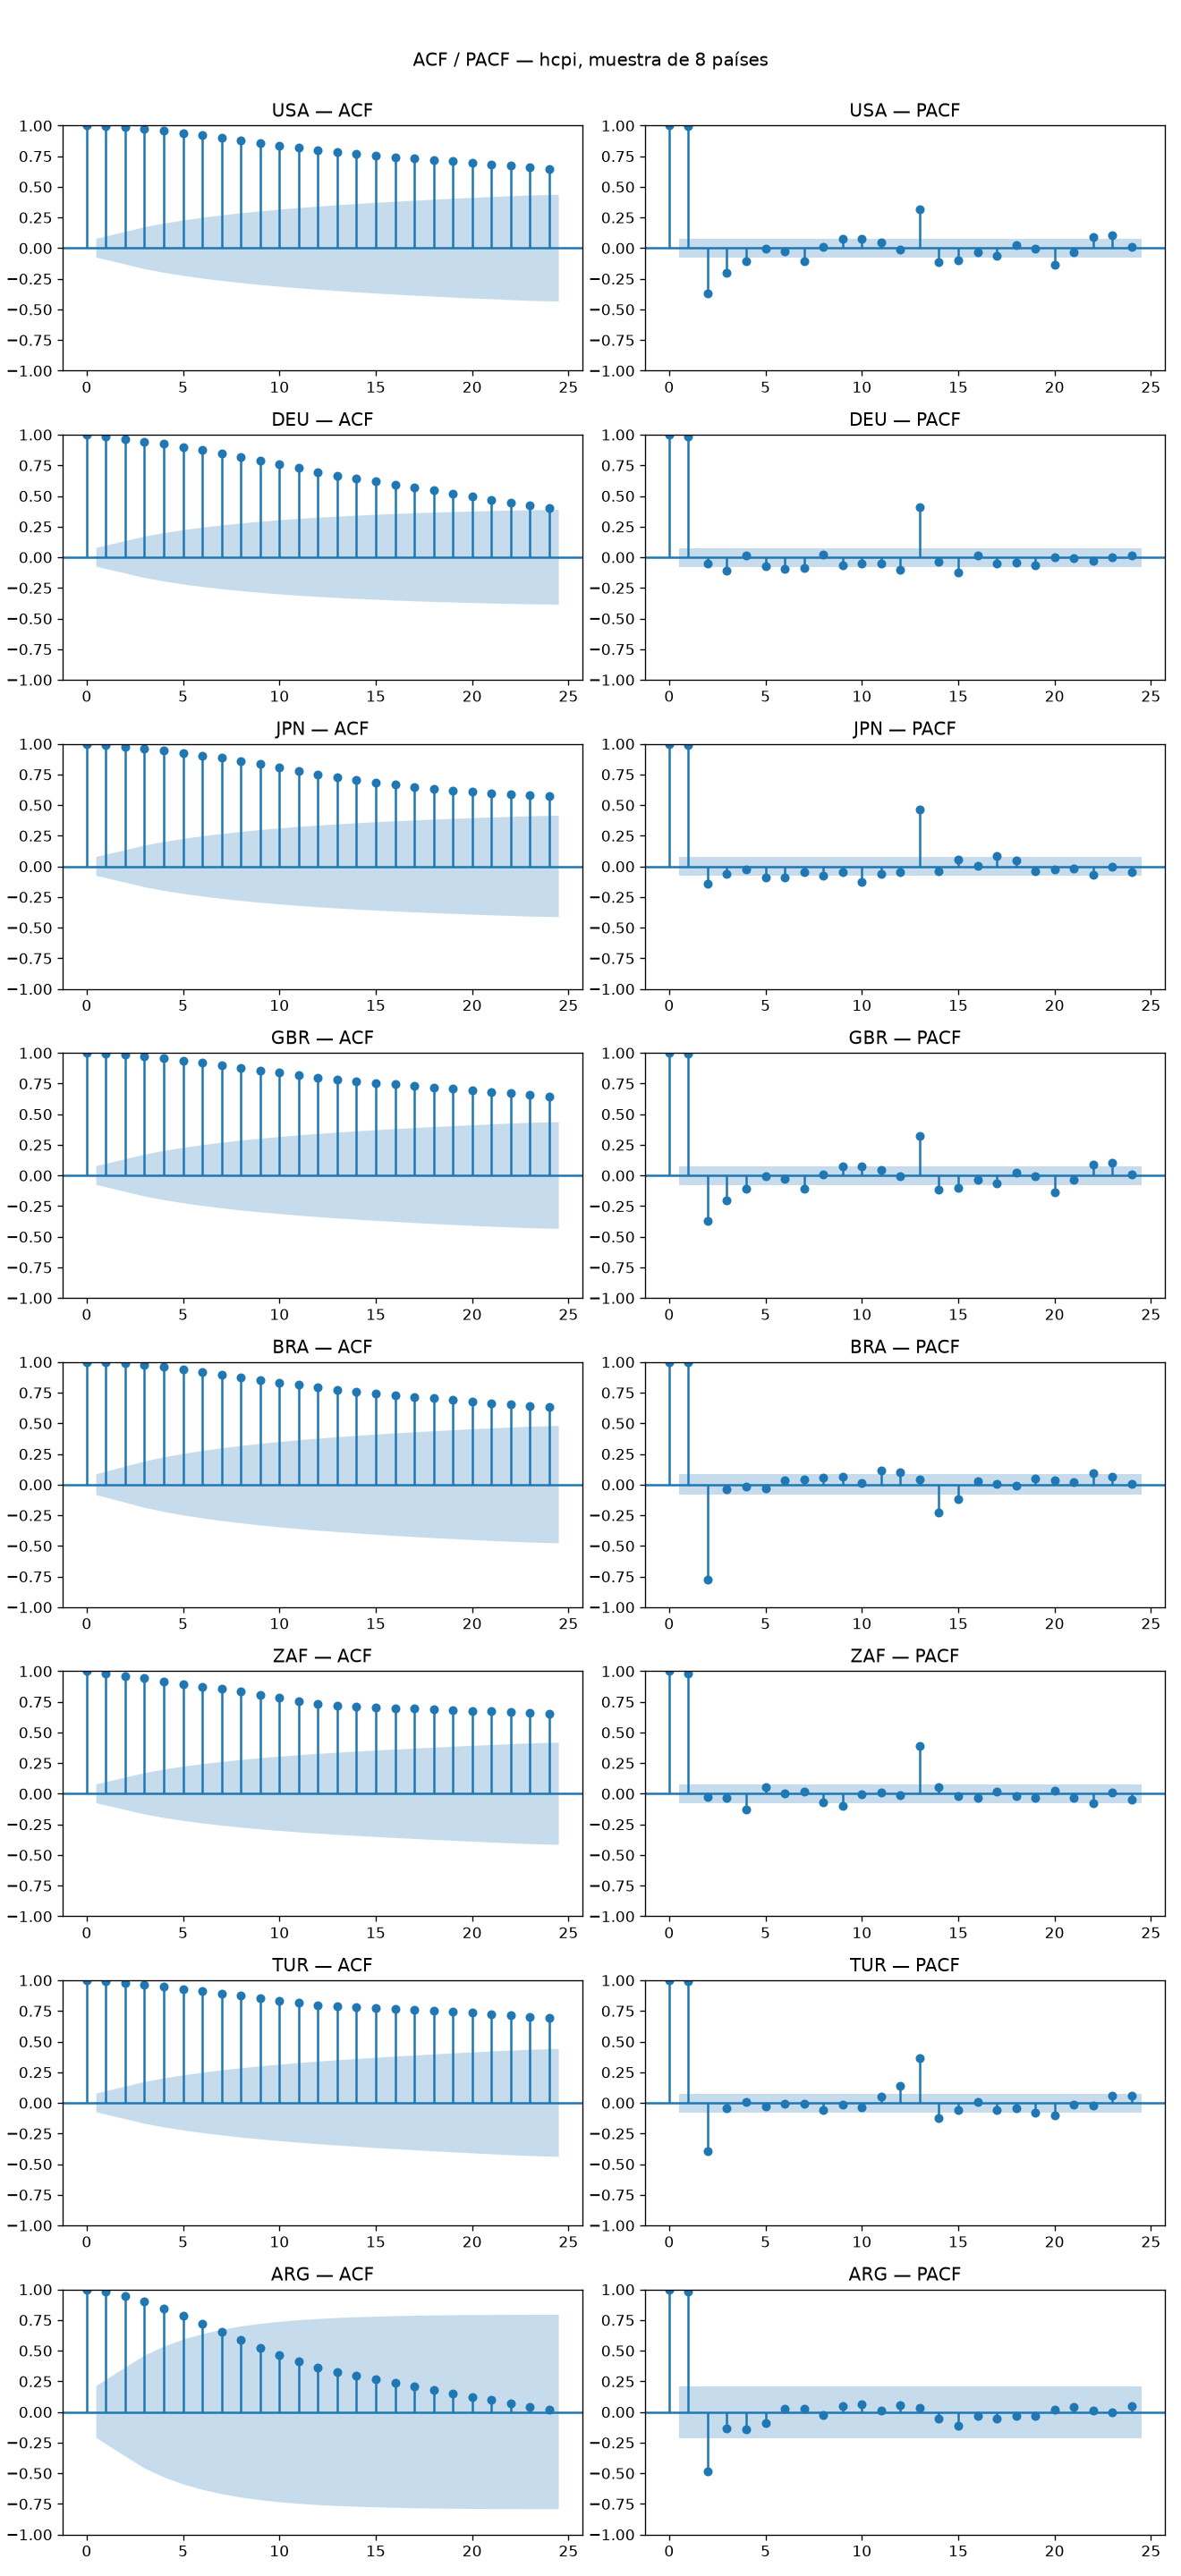

In [6]:
display(Image(filename=str(FIGS / "fase5_acf_pacf_muestra.png")))

**Una lección metodológica que quedó documentada en esta fase, y que se repitió más adelante:** la ACF en el lag 12 parecía "significativa" en 69% de las series — sugiriendo estacionalidad generalizada — pero eso resultó ser un artefacto de la persistencia general de `inflacion_yoy_log` (una ventana móvil de 12 meses arrastra correlación en casi cualquier lag corto). La PACF, que aísla el aporte propio del lag 12, la mostró significativa en solo 26% — la métrica correcta, no la más obvia, es la que hay que usar. Conclusión: no se justifica SARIMA como default para todo el panel.

---
## 3. Limpieza: el ETL corregido

Con las 5 fases de diagnóstico completas, se diseñó (y se hizo aprobar explícitamente, como un checklist de 10 pasos, antes de escribir una sola línea) el ETL corregido. Estos son los pasos con más impacto en los datos, con ejemplos concretos.

### Ejemplo 1 — India, energía: de "basura" a tasa correcta

India en `ecpi_m` ya viene con `Indicator Type='Inflation'` — el valor **ya es una tasa interanual**, no un índice. El ETL original (previo a la corrección) no distinguía esto y le aplicaba `pct_change` igual que a todo el resto, calculando "la variación porcentual de una variación porcentual" — sin sentido económico.

In [7]:
old = pd.read_parquet(ROOT / "data" / "processed" / "inflacion_mensual_completa.parquet")
india_antes = old[(old["codigo_pais"] == "IND") & (old["indicador"] == "ecpi")].sort_values("fecha")
india_despues = df[(df["codigo_pais"] == "IND") & (df["indicador"] == "ecpi")].sort_values("fecha")

print("ANTES (ETL original) - inflacion YoY calculada mal sobre una fila que ya era tasa:")
print(f"  rango: [{india_antes['inflacion_yoy'].min():.1f}%, {india_antes['inflacion_yoy'].max():.1f}%]  <- numeros sin sentido economico")
print()
print("DESPUES (ETL corregido, tratamiento_indicator_type='tasa_directa'):")
print(f"  rango: [{india_despues['inflacion_yoy_pct'].min():.1f}%, {india_despues['inflacion_yoy_pct'].max():.1f}%]  <- inflacion real de India")

ANTES (ETL original) - inflacion YoY calculada mal sobre una fila que ya era tasa:
  rango: [-inf%, inf%]  <- numeros sin sentido economico

DESPUES (ETL corregido, tratamiento_indicator_type='tasa_directa'):
  rango: [-11.3%, 34.6%]  <- inflacion real de India


### Ejemplo 2 — Venezuela: ceros que no eran ceros

Índice de precios de energía en 0.0 exacto durante ~60 meses no es un dato — es un placeholder. El ETL corregido lo trata como faltante (`NaN`), lo que lo convierte en un hueco interno de la serie en vez de una observación válida de "colapso total de precios".

In [8]:
ven = df[(df["codigo_pais"] == "VEN") & (df["indicador"] == "ecpi")].sort_values("fecha")
print(f"Venezuela / ecpi tras la correccion: {len(ven)} filas, de {ven['fecha'].min().date()} a {ven['fecha'].max().date()}")
print(f"Filas con indice == 0: {(ven['indice'] == 0).sum()}  (los ceros ya no estan presentes como filas)")

Venezuela / ecpi tras la correccion: 82 filas, de 2018-01-01 a 2024-10-01


Filas con indice == 0: 0  (los ceros ya no estan presentes como filas)


### Ejemplo 3 — Duplicados: dos series distintas bajo el mismo país

36 país-hoja tenían `Country Code` duplicado en el Excel crudo — no la misma serie repetida, sino **dos vintages/bases distintas** de la misma medida. Austria en `ppi_m` es el caso de manual: una fila cubre 1987-2024 (453 puntos), la otra 2000-2025 (302 puntos) — la regla del ETL se queda con la más completa, y marca con un flag (`dedup_conflicto_recencia`) los 8 casos donde eso implica sacrificar meses recientes por más historia.

In [9]:
raw = pd.read_excel(ROOT / "data" / "raw" / "Inflation-data.xlsx", sheet_name="ppi_m")
aut = raw[raw["Country Code"] == "AUT"]
date_cols = [c for c in raw.columns if isinstance(c, int) and 190001 <= c <= 210012]
for _, row in aut.iterrows():
    vals = row[date_cols].dropna()
    print(f"  fila con {len(vals)} puntos validos, de {vals.index.min()} a {vals.index.max()}")

print()
n_conflicto = df.drop_duplicates(subset=["codigo_pais", "indicador"])["dedup_conflicto_recencia"].sum()
print(f"Series con dedup_conflicto_recencia=True en el resultado final: {n_conflicto}")

  fila con 453 puntos validos, de 198701 a 202409
  fila con 302 puntos validos, de 200001 a 202502

Series con dedup_conflicto_recencia=True en el resultado final: 8


### Los 10 pasos completos

1. Cargar las 5 hojas mensuales crudas (`def` queda fuera — no tiene versión mensual).
2. Filtrar filas no-país explícitamente (regex ISO3), antes del melt.
3. Deduplicar por país, quedándose con la fila más completa — con flag de trazabilidad para los 8 casos límite.
4. Ramificar por `Indicator Type` real: India/Indonesia como tasa directa; Islas Vírgenes Británicas/Australia como índice pese a la etiqueta.
5. Tratar los ceros de Venezuela como dato faltante, no como nivel real.
6. Calcular **ambas** transformaciones: `inflacion_yoy_pct` (interpretable) e `inflacion_yoy_log` (para modelar).
7. Detectar y marcar el patrón de frecuencia por serie (mensual/trimestral/mixto) sin remuestrear automáticamente.
8. Flag `alta_inflacion` (>100% en algún punto) sin winsorizar.
9. Flags de cobertura y aptitud (`apto_arima`, `apto_garch`) sin borrar ninguna fila.
10. Guardar con trazabilidad completa — 15 columnas, ninguna decisión de limpieza silenciosa.

El resultado: **676 series país×indicador**, de las cuales **640 son aptas para ARIMA** y **626 para GARCH**.

---
## 4. Modelado: ARIMA + GARCH, en dos preguntas separadas

Este proyecto responde **dos preguntas distintas** para cada serie, con dos modelos distintos:

- **ARIMA** ("AutoRegressive Integrated Moving Average"): ¿el *nivel* de la inflación del próximo mes se puede pronosticar a partir de su propia historia? Combina tres ingredientes — cuánto pesa el pasado reciente (AR), cuántas veces hay que diferenciar la serie para que sea estacionaria (I), y cuánto pesa el error de pronóstico reciente (MA). Se ajusta con `auto_arima`, que prueba automáticamente combinaciones de estos tres números y elige la que mejor balancea ajuste y simplicidad (criterio AICc).

- **GARCH** ("Generalized AutoRegressive Conditional Heteroskedasticity"): no busca predecir el *nivel*, busca predecir la *volatilidad* — ¿los shocks de inflación vienen en rachas (un mes volátil tiende a ser seguido por otro mes volátil) o son ruido puro mes a mes? Se ajusta sobre los **residuos** del ARIMA (lo que el modelo de nivel no explicó), y el parámetro clave es la **persistencia** (`alpha + beta`): cuánto tarda un shock de volatilidad en disiparse. Persistencia cerca de 1 significa que un shock de volatilidad de hoy sigue siendo relevante dentro de muchos meses.

**Validación walk-forward**: en vez de un solo corte train/test, se evalúa con el origen de pronóstico avanzando de a un mes durante una ventana de 24 meses, re-estimando el modelo completo cada 6 pasos. Contra esto se compara siempre un **baseline ingenuo** (random walk: "el próximo valor es igual al último observado") — la prueba de honestidad de si el modelo aporta algo sobre lo trivial.

### Un ejemplo concreto: Estados Unidos vs. Argentina

Para que se vea, no solo se lea: acá se ajustan en vivo dos modelos ARIMA ilustrativos (no forman parte del pipeline batch de 640 series) sobre dos países con perfiles opuestos.

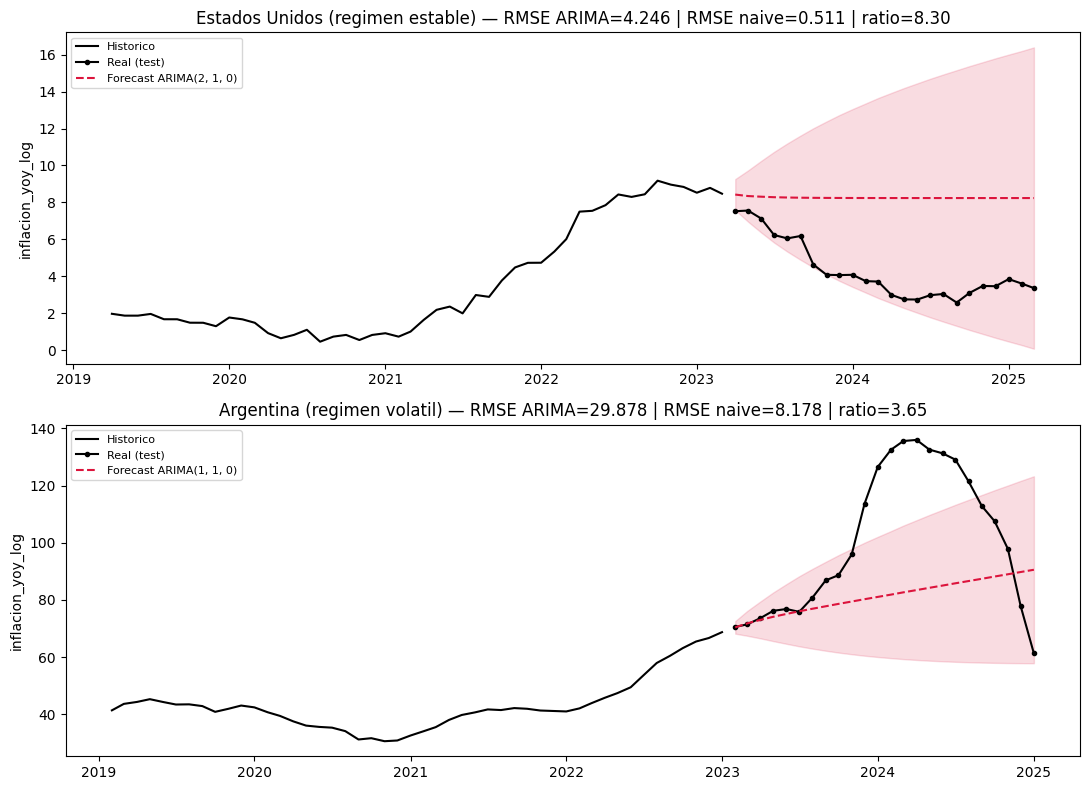

In [10]:
import pmdarima as pm

def ejemplo_arima(codigo, indicador="hcpi", meses_test=24):
    serie = df[(df["codigo_pais"] == codigo) & (df["indicador"] == indicador)].sort_values("fecha")
    serie = serie.dropna(subset=["inflacion_yoy_log"])
    y = serie["inflacion_yoy_log"].to_numpy()
    fechas = serie["fecha"].to_numpy()
    train, test = y[:-meses_test], y[-meses_test:]
    fechas_test = fechas[-meses_test:]

    modelo = pm.auto_arima(train, max_p=5, max_q=5, max_d=2, seasonal=False,
                            information_criterion="aicc", suppress_warnings=True)
    forecast, ci = modelo.predict(n_periods=meses_test, return_conf_int=True)
    naive = np.r_[train[-1], test[:-1]]

    rmse_arima = np.sqrt(np.mean((test - forecast) ** 2))
    rmse_naive = np.sqrt(np.mean((test - naive) ** 2))
    return serie, fechas_test, test, forecast, ci, modelo.order, rmse_arima, rmse_naive


fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)
for ax, codigo, nombre in zip(axes, ["USA", "ARG"], ["Estados Unidos (regimen estable)", "Argentina (regimen volatil)"]):
    serie, fechas_test, test, forecast, ci, orden, rmse_a, rmse_n = ejemplo_arima(codigo)
    serie_hist = serie[serie["fecha"] < fechas_test[0]].tail(48)

    ax.plot(serie_hist["fecha"], serie_hist["inflacion_yoy_log"], color="black", label="Historico")
    ax.plot(fechas_test, test, color="black", linestyle="-", marker="o", markersize=3, label="Real (test)")
    ax.plot(fechas_test, forecast, color="crimson", linestyle="--", label=f"Forecast ARIMA{orden}")
    ax.fill_between(fechas_test, ci[:, 0], ci[:, 1], color="crimson", alpha=0.15)
    ax.set_title(f"{nombre} — RMSE ARIMA={rmse_a:.3f} | RMSE naive={rmse_n:.3f} | ratio={rmse_a/rmse_n:.2f}")
    ax.legend(fontsize=8)
    ax.set_ylabel("inflacion_yoy_log")

fig.tight_layout()
plt.show()

El contraste es exactamente el que sugiere la intuición económica: en EE.UU. (inflación baja y estable) el intervalo de confianza del forecast es angosto pero el modelo apenas le gana al ingenuo — no hay mucho que predecir cuando el mes que viene ya se parece al anterior. En Argentina, el modelo captura la tendencia de fondo mucho mejor que "repetir el último valor" — hay estructura real que explotar quo aparece justo cuando el país cambia de régimen. Este contraste es, en miniatura, el hallazgo central de todo el proyecto (Sección 5.1).

### Un vistazo a la volatilidad (GARCH)

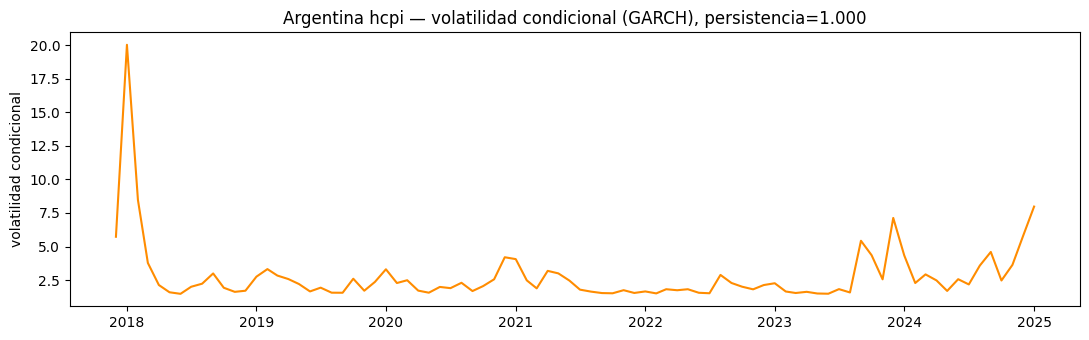

In [11]:
from arch import arch_model

serie_arg, fechas_test, test, forecast, ci, orden, _, _ = ejemplo_arima("ARG")
serie_full = df[(df["codigo_pais"] == "ARG") & (df["indicador"] == "hcpi")].dropna(subset=["inflacion_yoy_log"]).sort_values("fecha")
y_full = serie_full["inflacion_yoy_log"].to_numpy()

modelo_completo = pm.auto_arima(y_full, max_p=5, max_q=5, max_d=2, seasonal=False,
                                 information_criterion="aicc", suppress_warnings=True)
residuos = modelo_completo.resid()
garch = arch_model(residuos, vol="Garch", p=1, q=1, rescale=True).fit(disp="off")

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(serie_full["fecha"], garch.conditional_volatility, color="darkorange")
ax.set_title(f"Argentina hcpi — volatilidad condicional (GARCH), persistencia={garch.params['alpha[1]']+garch.params['beta[1]']:.3f}")
ax.set_ylabel("volatilidad condicional")
fig.tight_layout()
plt.show()

Se ven claramente rachas de volatilidad — no es ruido uniforme, hay períodos tranquilos y períodos turbulentos que se agrupan en el tiempo. Eso es exactamente lo que GARCH está diseñado para capturar, y es una pregunta distinta de "¿el nivel es predecible?" (Sección 5.4 profundiza en esta distinción).

---
## 5. Resultados y hallazgos

Con el pipeline completo corrido sobre las 640-626 series aptas, estos son los cinco hallazgos centrales. Cada uno se probó estadísticamente, no se afirma por impresión visual.

In [12]:
resultados = pd.read_parquet(ROOT / "data" / "processed" / "resultados_enriquecidos.parquet")
print(f"Series con resultado de modelado: {len(resultados)}")
print(f"Series con ARIMA convergido: {resultados['convergio_arima'].sum()}")
print(f"Series con GARCH convergido: {resultados['convergio_garch'].sum()}")
resultados.head(3)

Series con resultado de modelado: 640
Series con ARIMA convergido: 640
Series con GARCH convergido: 626


,codigo_pais,indicador,pais,meses_usados,estacionalidad_detectada,convergio_arima,motivo_fallo_arima,orden_p,orden_d,orden_q,...,arima_supera_naive,std_error_walkforward,convergio_garch,motivo_fallo_garch,omega,alpha,beta,persistencia,region,nivel_ingreso
0,ABW,ecpi,Aruba,218,False,True,None,1,1,0,...,False,0.678417,True,NaN,0.240942,0.081799,0.885823,0.967622,Latin America & Caribbean,High income
1,ABW,hcpi,Aruba,218,False,True,None,1,1,0,...,False,0.648556,True,NaN,0.021138,0.082392,0.903632,0.986025,Latin America & Caribbean,High income
2,AFG,fcpi,Afghanistan,229,False,True,None,3,0,3,...,True,2.051659,True,NaN,0.475611,0.223369,0.745969,0.969338,"Middle East, North Africa, Afghanistan & Pakistan",Low income


### 5.1 — El gradiente de previsibilidad por nivel de ingreso

El RMSE walk-forward mediano de headline CPI baja monótonamente de países de bajos ingresos a altos ingresos.

nivel_ingreso
Low income             1.701389
Lower middle income    0.849010
Upper middle income    0.702898
High income            0.537629
Name: rmse_arima_walkforward, dtype: float64



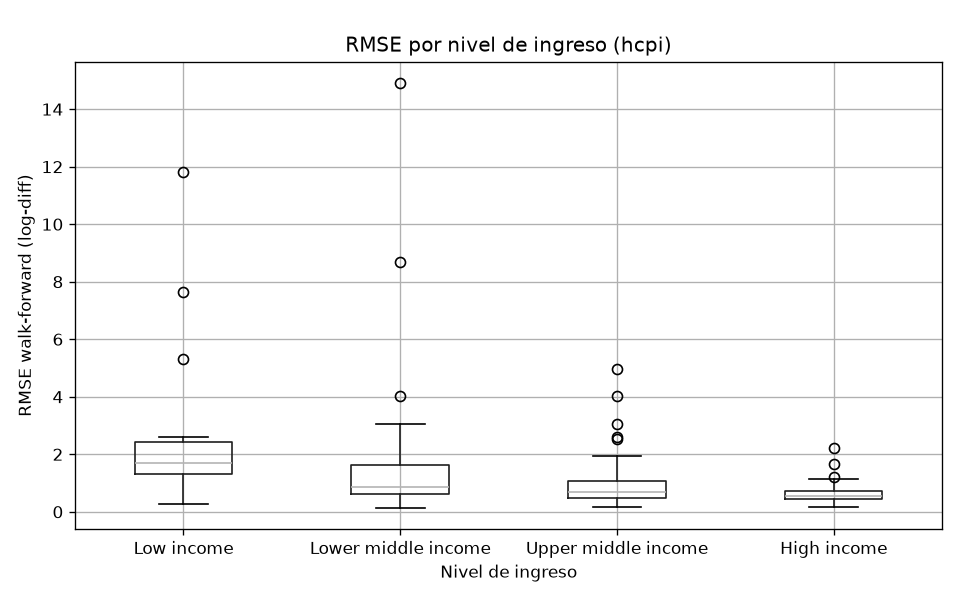

In [13]:
orden_ingreso = ["Low income", "Lower middle income", "Upper middle income", "High income"]
hcpi = resultados[(resultados["indicador"] == "hcpi") & (resultados["convergio_arima"]) & (resultados["nivel_ingreso"].notna())]
print(hcpi.groupby("nivel_ingreso")["rmse_arima_walkforward"].median().reindex(orden_ingreso))
print()
display(Image(filename=str(FIGS / "analisisA_boxplot_ingreso.png")))

**Kruskal-Wallis: H=31.85, p=5.6×10⁻⁷.** El problema obvio es que los países ricos también tienen series más largas — se puso a prueba con correlación parcial (sobrevive: ρ=-0.33, p=7.9×10⁻⁶) y truncando todas las series a la misma longitud y re-modelando desde cero (sobrevive: Kruskal-Wallis p=2.3×10⁻⁶). Detalle completo en la Sección 6.

### 5.2 — No es "cuánta" inflación, es su forma

La hipótesis obvia — más inflación, menos previsible — no se sostiene como relación general (Mann-Whitney p=0.54; correlación continua p=0.18). Mirando de cerca las series de inflación >20%, la razón aparece clara.

In [14]:
inflacion = df.groupby(["codigo_pais", "indicador"])["inflacion_yoy_pct"].mean().reset_index(name="inflacion_media_pct")
panel = resultados.merge(inflacion, on=["codigo_pais", "indicador"], how="left")
alta = panel[(panel["inflacion_media_pct"].abs() > 20) & panel["ratio_vs_naive"].notna()]
ejemplos = alta[alta["codigo_pais"].isin(["ARG", "VEN", "LTU", "ZWE", "SSD", "LVA"])][
    ["codigo_pais", "indicador", "inflacion_media_pct", "ratio_vs_naive"]
].sort_values("ratio_vs_naive")
ejemplos.columns = ["pais", "indicador", "inflacion_media_%", "ratio_vs_naive (<1 = ARIMA gana)"]
ejemplos

,pais,indicador,inflacion_media_%,ratio_vs_naive (<1 = ARIMA gana)
346,LTU,hcpi,52.488761,0.551364
16,ARG,hcpi,86.887963,0.608856
618,VEN,hcpi,85.715574,0.618277
15,ARG,fcpi,89.513685,0.619646
355,LVA,fcpi,33.821390,0.657426
617,VEN,fcpi,28448.805329,0.723180
619,VEN,ppi,10209.666460,0.760997
17,ARG,ppi,80.547644,0.872150
14,ARG,ecpi,85.835647,0.995241
534,SSD,hcpi,62.615598,1.046603


Argentina, Venezuela y Lituania — inflación alta pero con **tendencia sostenida** que un modelo lineal puede seguir — están entre las series donde ARIMA más le gana al random walk. Zimbabwe, Sudán del Sur y Letonia — inflación alta pero con **saltos discontinuos y cambios de régimen abruptos** — están entre las que menos gana. Es la *forma* de la volatilidad, no su magnitud, lo que determina si un modelo lineal tiene algo que agarrar.

### 5.3 — El núcleo es más predecible, pero sus shocks no son más transitorios

Excluir alimentos y energía sí mejora la previsibilidad de nivel (Wilcoxon pareado, n=76 países, p=3.3×10⁻⁹), y ese orden se repite país por país (Friedman, n=57, p=3.9×10⁻³⁰).

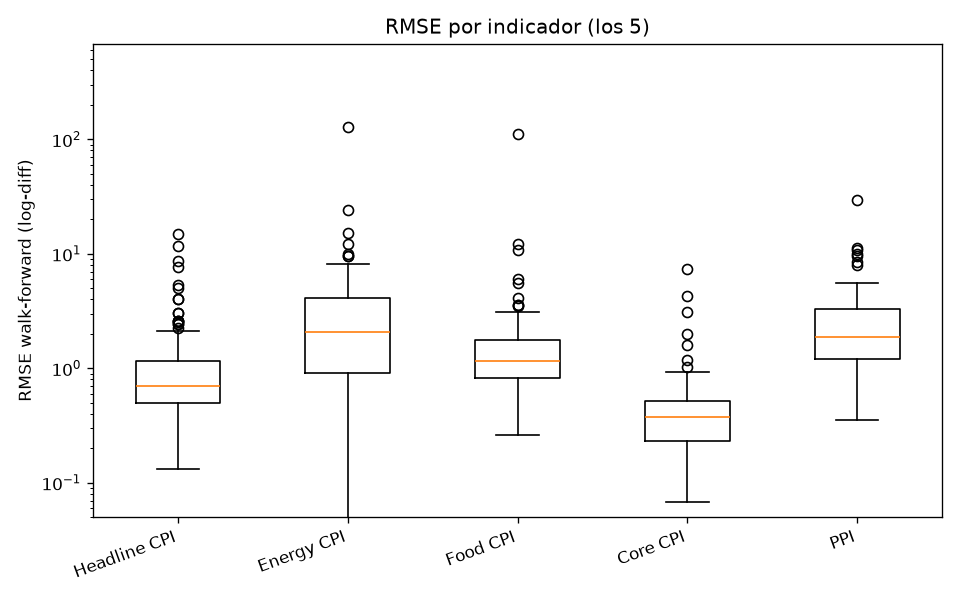

In [15]:
display(Image(filename=str(FIGS / "analisisB_boxplot_rmse_indicador.png")))

Pero acá aparece un resultado que contradice la intuición de "mirar a través" de los shocks de energía/alimentos en política monetaria: la **persistencia de volatilidad GARCH no difiere significativamente entre los 5 indicadores** (Kruskal-Wallis, p=0.12). Ser más predecible en *nivel* no implica que los shocks se disipen más rápido en *volatilidad* — que lleva directamente al siguiente hallazgo.

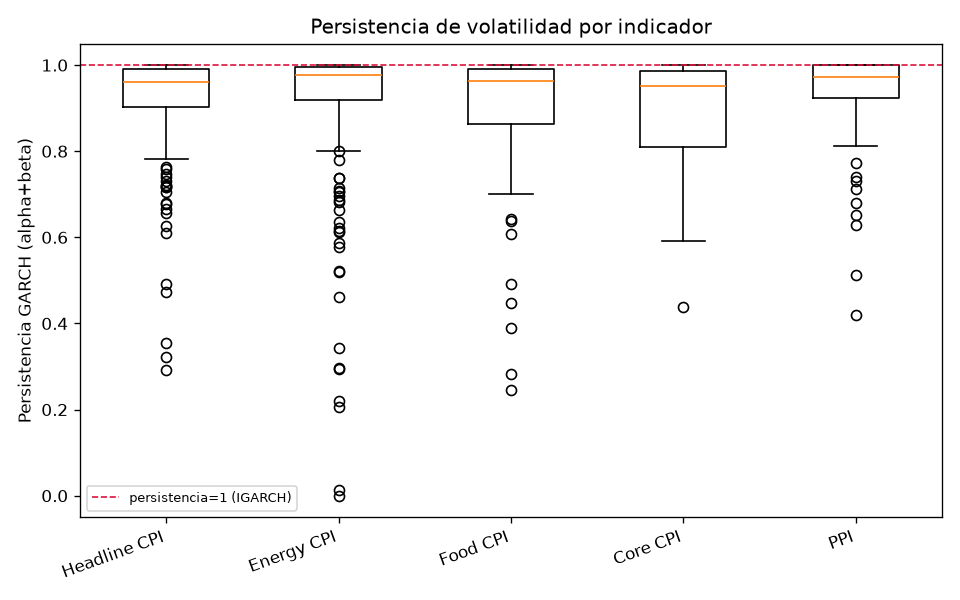

In [16]:
display(Image(filename=str(FIGS / "analisisB_boxplot_persistencia_indicador.png")))

### 5.4 — Previsibilidad de nivel y persistencia de volatilidad son dimensiones independientes

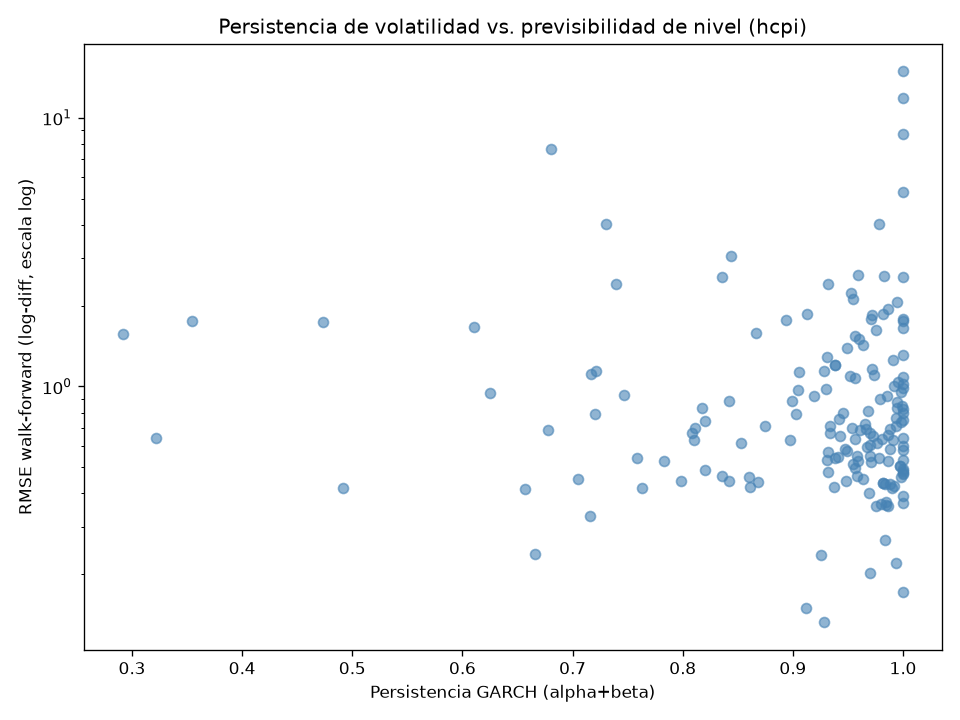

In [17]:
display(Image(filename=str(FIGS / "analisisC_scatter_persistencia_rmse.png")))

Correlación entre RMSE de nivel y persistencia GARCH: **ρ=-0.007, p=0.93** — prácticamente cero. Un país con inflación difícil de pronosticar no es necesariamente un país con volatilidad persistente. Son dos preguntas distintas que exigen dos modelos distintos — exactamente por eso este proyecto los trata por separado, en vez de asumir que uno implica el otro.

### 5.5 — El ranking honesto es de grupos, no de un orden país-a-país

Cada RMSE walk-forward viene de apenas 24 observaciones — tiene incertidumbre. Se calculó un intervalo de confianza por bootstrap (1000 iteraciones) para cada serie de headline.

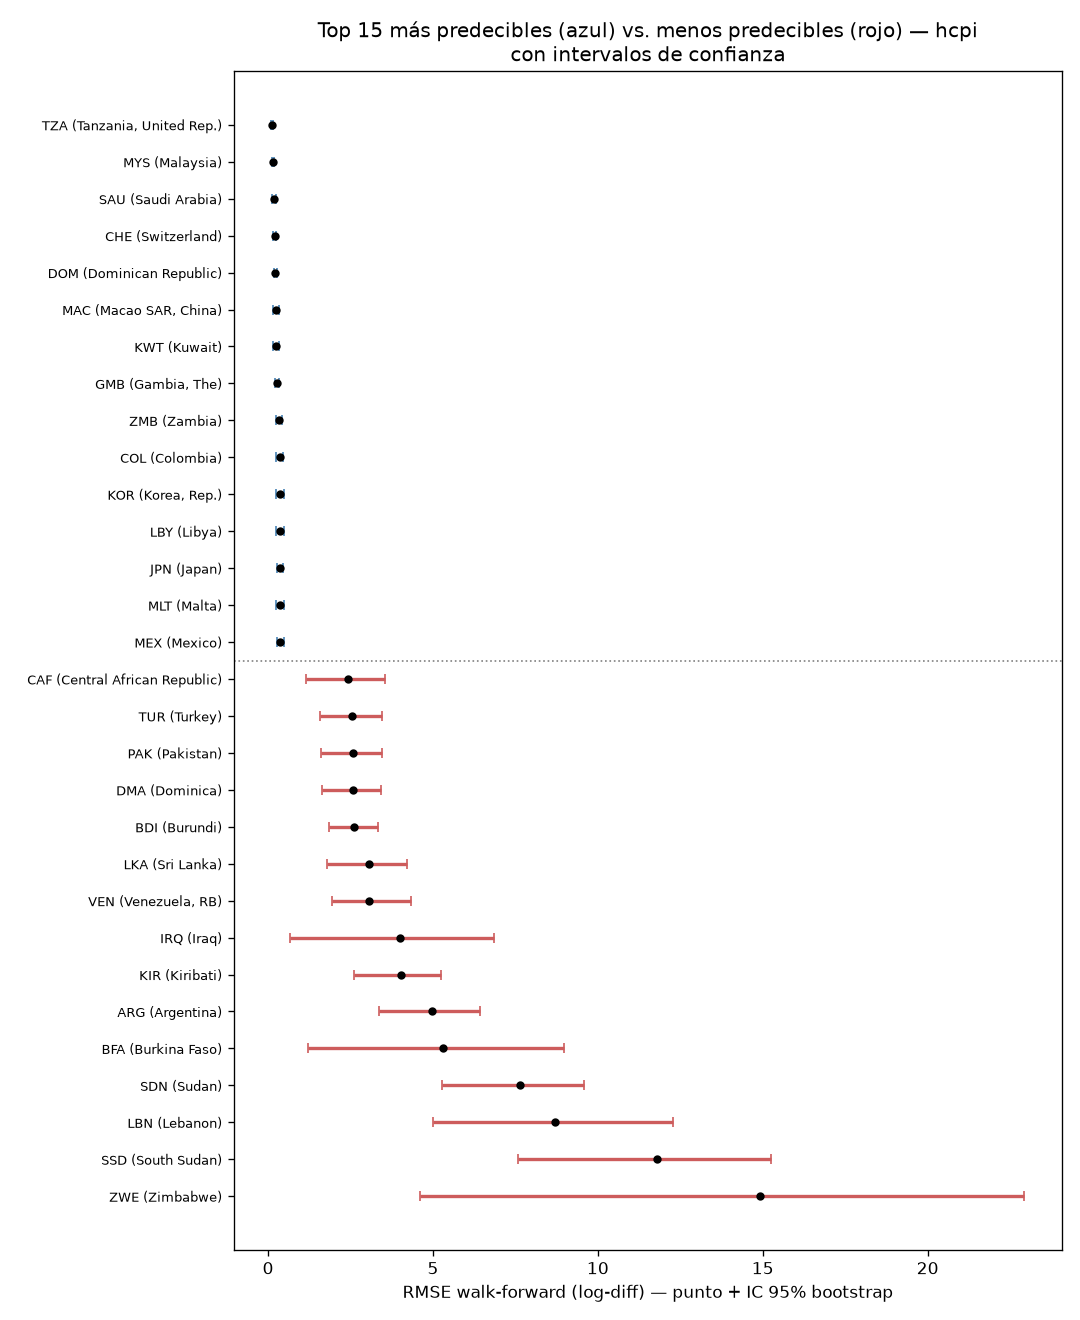

In [18]:
display(Image(filename=str(FIGS / "robustez_ranking_ci.png")))

**De los 173 pares de países consecutivos en el ranking completo, el 0% tiene intervalos que no se solapan.** Ningún país es "significativamente" más predecible que su vecino inmediato en la tabla — lo que sí es real son los extremos (un país del top 15 y uno del bottom 15 sí tienen intervalos separados). La lectura correcta no es una lista ordenada exacta: es un grupo consistentemente más predecible, un grupo consistentemente menos predecible, y una zona ancha e indistinguible en el medio.

---
## 6. Auto-auditoría: poniendo a prueba el hallazgo central

Antes de dar por bueno el gradiente de ingreso (5.1), el proyecto se sometió a su propia auditoría metodológica — midiendo el impacto real de dos debilidades posibles, en vez de asumirlas o descartarlas de antemano.

### 6.1 — ¿Hay data leakage en la selección de orden ARIMA?

Preocupación: si `auto_arima` elige `(p,d,q)` mirando toda la serie (incluido el período de evaluación), el RMSE walk-forward estaría artificialmente inflado. Se midió comparando, en una muestra de 48 países, el orden elegido viendo toda la serie vs. viendo solo el período de entrenamiento.

**Resultado**: el orden cambia en 60% de los casos, pero el impacto en RMSE no es distinguible de cero (Wilcoxon, p=0.70), y el ranking de países es casi idéntico con o sin leakage (Spearman ρ=0.996). Confirmado además que el pipeline real (`06b_modelado_robusto.py`) ya excluye la ventana de evaluación de la selección de orden desde el arranque — el leakage medido es un escenario contrafáctico, no algo presente en los resultados reportados.

### 6.2 — ¿El gradiente de ingreso es un artefacto de longitud de serie?

Los países ricos tienen series más largas (ρ=0.49 con ingreso) y las series más largas tienden a tener menor RMSE (ρ=-0.29) — el confusor es una posibilidad real, no una hipótesis inventada. Se puso a prueba dos veces: correlación parcial controlando por longitud (**sobrevive**, ρ=-0.33, p=7.9×10⁻⁶) y truncando las 174 series de headline a una longitud común (48 meses) y re-modelando desde cero (**sobrevive**, Kruskal-Wallis p=2.3×10⁻⁶).

### 6.3 — El modelo multivariado: todo junto, controlando por todo a la vez

In [19]:
import statsmodels.api as sm

hcpi_reg = hcpi.merge(inflacion, on=["codigo_pais", "indicador"], how="left")
hcpi_reg = hcpi_reg[hcpi_reg["convergio_garch"]].copy().reset_index(drop=True)
hcpi_reg["nivel_ingreso"] = pd.Categorical(hcpi_reg["nivel_ingreso"], categories=orden_ingreso, ordered=False)
hcpi_reg["log_rmse"] = np.log(hcpi_reg["rmse_arima_walkforward"])
hcpi_reg["log_inflacion"] = np.log1p(hcpi_reg["inflacion_media_pct"].abs())

dummies_ingreso = pd.get_dummies(hcpi_reg["nivel_ingreso"], prefix="ingreso", drop_first=True).astype(float)
X = pd.concat([dummies_ingreso, hcpi_reg[["log_inflacion", "meses_usados", "persistencia"]]], axis=1)
X = sm.add_constant(X)
modelo_ols = sm.OLS(hcpi_reg["log_rmse"], X).fit(cov_type="HC3")

print(f"N = {len(hcpi_reg)} paises | R2 = {modelo_ols.rsquared:.3f}")
print()
tabla_coef = pd.DataFrame({
    "coeficiente": modelo_ols.params,
    "p-valor": modelo_ols.pvalues,
}).round(4)
tabla_coef["significativo"] = tabla_coef["p-valor"] < 0.05
tabla_coef

N = 171 paises | R2 = 0.289



,coeficiente,p-valor,significativo
const,0.2078,0.6595,False
ingreso_Lower middle income,-0.5261,0.0271,True
ingreso_Upper middle income,-0.7092,0.0016,True
ingreso_High income,-0.7873,0.0007,True
log_inflacion,0.2545,0.0101,True
meses_usados,-0.0009,0.0046,True
persistencia,-0.0304,0.9470,False


*(Nota: esta regresión se ajusta en vivo — es rápida, no forma parte del pipeline batch — sobre región omitida por brevedad; el modelo completo con dummies de región está en `reports/robustez_multivariado.md`, R²=0.315.)*

`log(RMSE) ~ ingreso + inflación media + longitud de serie + persistencia GARCH`, controlando todo simultáneamente: las tres categorías de ingreso siguen siendo significativas y monótonas, la inflación media aporta información propia más allá del ingreso, la longitud de serie sigue siendo significativa (aunque con coeficiente chico), y la persistencia GARCH no es significativa — consistente con el hallazgo 5.4.

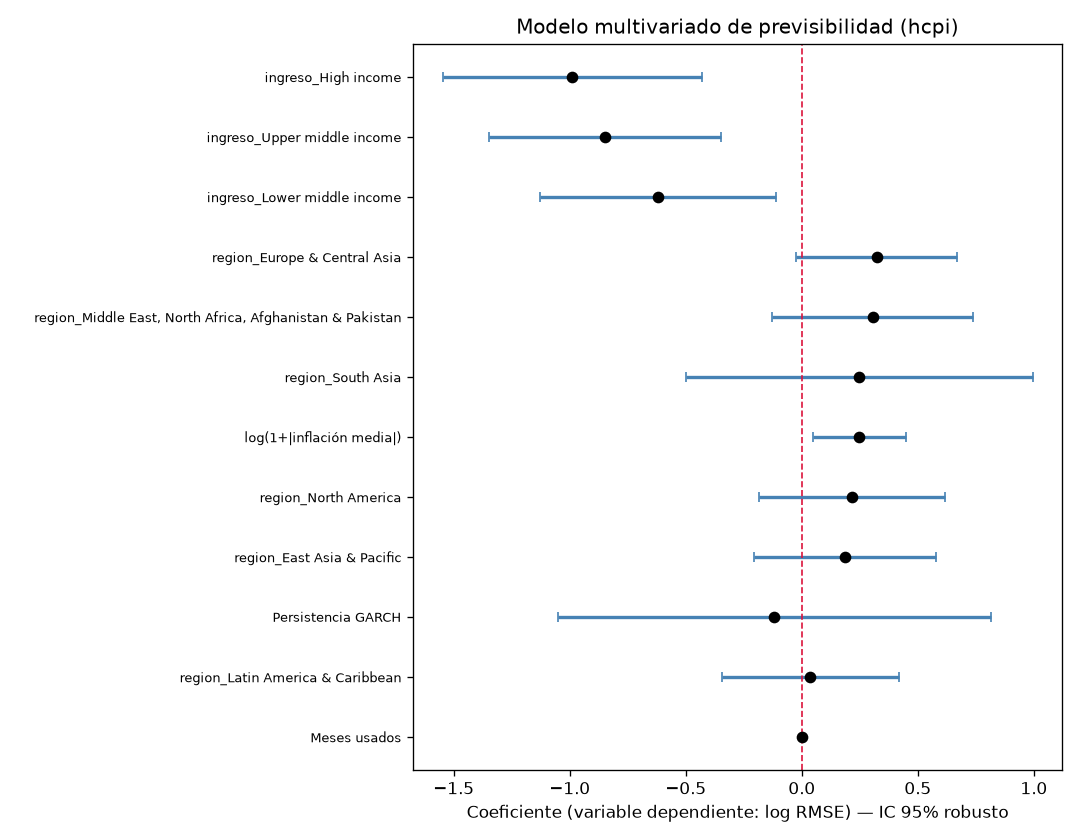

In [20]:
display(Image(filename=str(FIGS / "robustez_coeficientes_ols.png")))

El resultado de las cuatro pruebas independientes (bivariado, correlación parcial, truncamiento, modelo multivariado) es el mismo: **el gradiente de ingreso sobrevive.** No es un artefacto de longitud de datos.

---
## 7. Limitaciones honestas

- **Panel no balanceado por diseño**: no se excluyó a ningún país por tener historia corta — el desbalance es intencional, para no sesgar la muestra hacia economías estables. La Sección 6.2 confirma que esto no explica el hallazgo central, pero las comparaciones entre países siguen sin ser "de igual a igual" en cantidad de información.
- **Algunas series de alto interés nunca llegan a GARCH**: el piso de 100 meses sin huecos deja afuera a Argentina (headline, 86 meses) y Venezuela (energía/alimentos/headline, 70-79 meses) — no por ser demasiado volátiles (las series de estos países que sí cumplen el piso convergen sin problema, varias en el borde IGARCH), sino por cobertura de datos insuficiente.
- **Un solo tipo de modelo por dimensión**: ARIMA lineal, GARCH(1,1) simétrico. Ninguna variante no lineal.
- **Componente estacional no explotado**: ~26% de las series tienen señal estacional propia genuina (PACF en lag 12), pero el pipeline no usa SARIMA en ningún caso.
- **El ranking país-a-país tiene más incertidumbre de la que aparenta** (5.5) — cualquier lectura del ranking como lista ordenada exacta está sobre-interpretando el resultado.

## Trabajo futuro

- **Modelos de volatilidad asimétricos** (EGARCH, GJR-GARCH): el GARCH(1,1) simétrico no distingue sorpresas al alza de sorpresas a la baja.
- **Contagio entre países** (VAR / cointegración): cada serie se modeló de forma independiente; una pregunta natural es si shocks en un país predicen shocks en sus socios comerciales.
- **Dimensión temporal**: ¿cambió la previsibilidad tras la adopción de metas de inflación explícitas en los 90? El panel tiene profundidad histórica (desde 1970) para un diseño de quiebre estructural.
- **Variables institucionales externas**: independencia del banco central, régimen cambiario, apertura comercial — el modelo actual (R²=0.315) deja bastante varianza sin explicar.


---
## 8. Conclusión

La inflación no es igual de predecible en todas partes, y la diferencia no es ruido de muestreo: los países de mayores ingresos tienen inflación sistemáticamente más previsible, ese gradiente sobrevivió cuatro intentos independientes de tirarlo abajo, y lo que separa a un país predecible de uno impredecible no es cuánta inflación tiene sino si esa inflación se mueve con una tendencia reconocible o a los saltos.

Igual de importante que los hallazgos es cómo se llegó a ellos: cinco fases de diagnóstico antes de tocar un dato, un ETL con trazabilidad completa de cada corrección, una evaluación honesta contra un baseline trivial, y una auto-auditoría que midió — no asumió — el riesgo de sus propios puntos débiles. El ranking de previsibilidad país por país, que a primera vista parece el resultado más vendible del proyecto, terminó siendo el que exigió más matiz: la respuesta rigurosa no es una lista ordenada, es un mapa de qué tan seguro se puede estar de cada comparación.

Ese balance — resultados claros, comunicados con la incertidumbre que realmente tienen — es, más que cualquier número puntual, el resultado de este proyecto.

---
*Repositorio completo, pipeline reproducible y los 12 informes de fase/análisis en detalle: ver `README.md` y `reports/`.*
